In [44]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [45]:
from pathlib import Path
import sys

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rsatoolbox

from diffusion_brain_alignment.data.things_monkey_ephys import (
    _metadata,
    area_channels,
    download,
    load_test_repetitions,
    sample_trials,
)

In [46]:
# config

MONKEY = "monkeyN"
ROIS = ["V1", "V4", "IT"] # \in {"V1", "V4", "IT"}

RDM_METHOD = "correlation"
COMPARE_METHODS = ["corr", "spearman"]
# must be \in rsatoolbox.rdm.compare method list

# same-area resamples

N_SPLITS = 25  # n. split-half resamples for the noise ceiling
SEED = 0 # only for sampling the random-split

AREA_COLORS = {"V1": "#4C72B0", "V4": "#DD8452", "IT": "#55A868"}

area_channels[MONKEY]

{'V1': (0, 512), 'V4': (512, 768), 'IT': (768, 1024)}

In [47]:
download(monkey=MONKEY)

In [48]:
test_names = _metadata()["test"]
n_test = len(test_names)

trials = sample_trials(monkey=MONKEY, split="test", n_samples=n_test)

reps = {roi: load_test_repetitions(trials, roi=roi) for roi in ROIS}

{roi: array.shape for roi, array in reps.items()}

{'V1': (30, 100, 512), 'V4': (30, 100, 256), 'IT': (30, 100, 256)}

In [ ]:
def build_rdm(responses, method=RDM_METHOD, name=None):

    responses = np.asarray(responses, dtype=float)
    dataset = rsatoolbox.data.Dataset(
        responses, obs_descriptors={"index": np.arange(responses.shape[0])}
    )
    rdm = rsatoolbox.rdm.calc_rdm(dataset, method=method, descriptor="index")
    if name is not None:
        rdm.rdm_descriptors["name"] = [name]
    return rdm


def compare_rdms(rdms, method="corr"):
    return rsatoolbox.rdm.compare(rdms, rdms, method=method)


def split_half_reliability(area_reps, method=RDM_METHOD, compare_method="corr",
                           n_splits=N_SPLITS, seed=SEED):
    rng = np.random.default_rng(seed)
    n_reps = area_reps.shape[0]
    values = []
    for _ in range(n_splits):
        order = rng.permutation(n_reps)
        first, second = order[: n_reps // 2], order[n_reps // 2 :] # halve the repeated imgs
        rdm_a = build_rdm(np.nanmean(area_reps[first], axis=0), method)
        rdm_b = build_rdm(np.nanmean(area_reps[second], axis=0), method)

        values.append(float(rsatoolbox.rdm.compare(rdm_a, rdm_b, method=compare_method)[0][0]))
        # compare each side of the split's rdm

    return np.array(values)

In [ ]:
# inter-area comparison

mean_responses = {roi: np.nanmean(reps[roi], axis=0) for roi in ROIS}

rdms = rsatoolbox.rdm.concat([
    build_rdm(mean_responses[roi], name=roi) for roi in ROIS
])

for roi in ROIS:
    n_nan = np.isnan(rdms.get_matrices()[ROIS.index(roi)]).sum()
    if n_nan:
        print(f"WARNING {roi}: {n_nan} NaN dissimilarities — likely dead channels")


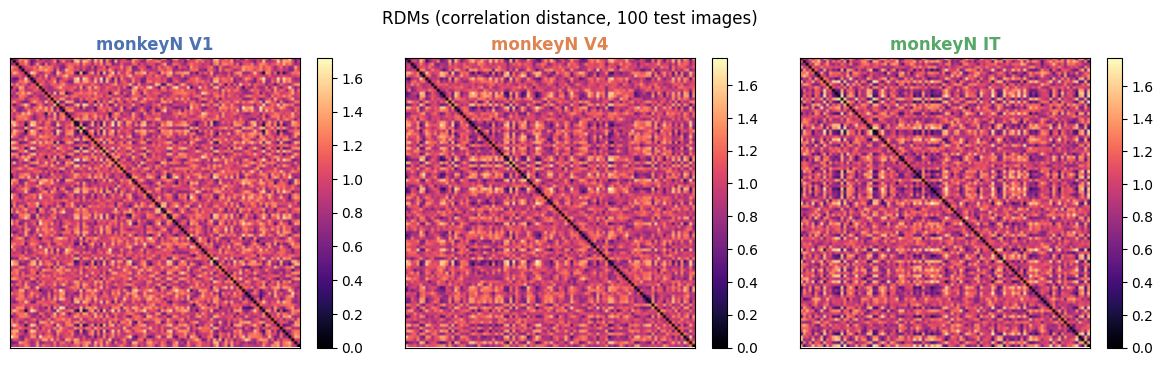

In [51]:
fig, axes = plt.subplots(1, len(ROIS), figsize=(4 * len(ROIS), 3.6))
for ax, roi in zip(axes, ROIS):
    matrix = rdms.get_matrices()[ROIS.index(roi)]
    image = ax.imshow(matrix, cmap="magma")
    ax.set_title(f"{MONKEY} {roi}", color=AREA_COLORS[roi], fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(image, ax=ax, fraction=0.046)
fig.suptitle(f"RDMs ({RDM_METHOD} distance, {n_test} test images)")
fig.tight_layout()
plt.show()

In [52]:
available = []
matrices = {}
for method in COMPARE_METHODS:
    try:
        matrices[method] = compare_rdms(rdms, method=method)
        available.append(method)
    except Exception as error:  # metric not in this rsatoolbox version
        print(f"skipping {method!r}: {error}")

pd.DataFrame(matrices[available[0]], index=ROIS, columns=ROIS).round(3)

,V1,V4,IT
V1,1.00,0.430,0.170
V4,0.43,1.000,0.425
IT,0.17,0.425,1.000


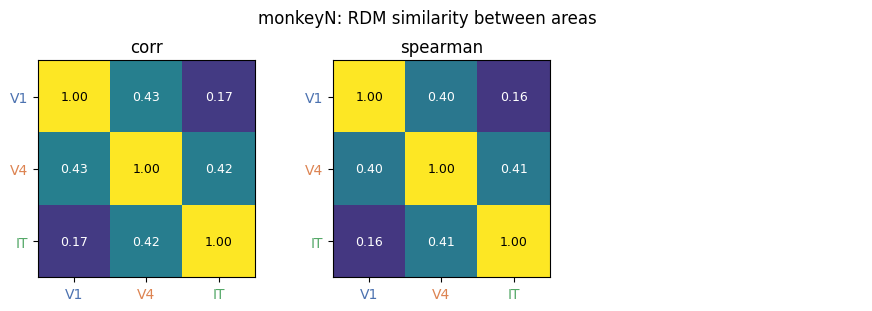

In [53]:
n_cols = 3
n_rows = int(np.ceil(len(available) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))

for ax, method in zip(np.ravel(axes), available):
    matrix = matrices[method]
    ax.imshow(matrix, cmap="viridis", vmin=0, vmax=1)
    for i in range(len(ROIS)):
        for j in range(len(ROIS)):
            ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center",
                    color="white" if matrix[i, j] < 0.6 else "black", fontsize=9)
    ax.set_xticks(range(len(ROIS)), ROIS)
    ax.set_yticks(range(len(ROIS)), ROIS)
    for label, roi in zip(ax.get_xticklabels() + ax.get_yticklabels(), ROIS + ROIS):
        label.set_color(AREA_COLORS[roi])
    ax.set_title(method)

for ax in np.ravel(axes)[len(available):]:
    ax.axis("off")

fig.suptitle(f"{MONKEY}: RDM similarity between areas")
fig.tight_layout()
plt.show()

In [54]:
# noise ceiling (intra-area comparisons)

reliability = {roi: split_half_reliability(reps[roi]) for roi in ROIS}

ceiling = pd.DataFrame(
    {
        "mean": {roi: values.mean() for roi, values in reliability.items()},
        "std": {roi: values.std() for roi, values in reliability.items()},
    }
).loc[ROIS]
ceiling.round(3)

,mean,std
V1,0.973,0.002
V4,0.982,0.002
IT,0.956,0.006


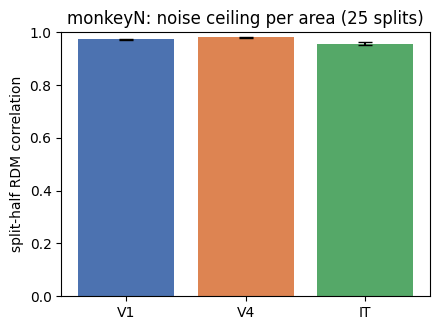

In [55]:
fig, ax = plt.subplots(figsize=(4.5, 3.4))
ax.bar(ROIS, ceiling["mean"], yerr=ceiling["std"], capsize=5,
       color=[AREA_COLORS[roi] for roi in ROIS])
ax.set_ylabel("split-half RDM correlation")
ax.set_ylim(0, 1)
ax.set_title(f"{MONKEY}: noise ceiling per area ({N_SPLITS} splits)")
fig.tight_layout()
plt.show()